### Fábio Luís de Carvalho Terra - 2321055

# 2ª Avaliação de Modelagem e Programação Estatística

O objetivo desta avaliação prática é escrever um relatório sobre a análise de dados demgráficos dos país. Os dados estão agrupados por estados e traz uma série (simples) de informações em colunas.

Para escrever o referido relatório, vocês deverão realizar a análise descritiva dos dados e verificarem eventuais outliers.

Façam as análises ora para os dados gerais do Brasil ora por regiões. Analisem os dados à luz da realidade de cada região brasileira (considerem as grandes áreas urbanas, por exemplo): os dados devem servir de embasamento para levantar hipóteses e tirar conclusões. Façam com calma e procurem utilizar o máximo de técnicas de análise descritiva e preditiva. Descrevam com o máximo de clareza a análise dos dados e relacionem as informações extraídas com dados de outras fontes que julgarem interessante ou auxiliar a análise de vocês.

Alguns apontamentos e perguntas para auxiliar na escrita do relatório:

1) Há outliers entre as variáveis?

2) Há relação entre as variáveis?

3) É possível fazer agrupamento e categorização dos dados (clusters)? Como isso é feito? (EXTRA)

4) É possível modelar os dados de densidade de 2022 a partir das demais variáveis numéricas? Em caso afirmativo, encontrem um modelo e todas os parâmetros relacionados à qualidade do ajuste.

5) Uma vez estabelecido um modelo (que pode ser por região) é possível prever qual será a região quer terá maior crescimento de densidade populacional para os próximos 

Façam o relatório explicando todas as análises e modelagens possíveis. Caso queiram, podem escrever o relatório como uma matéria de jornal (talvez ajude).

Lembrem-se que gráficos facilitam o entendimento e também a escrita, além de demonstrar o conhecimento adquirido por vocês e suas habilidades de análise.

Vocês terão até às 23h59 da quinta-feira, dia 27 para entrega.

Boa análise.


---


In [128]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

No código abaixo será importada as bibliotecas que serão utilizadas para a realização da análise, tendo em vista que cada biblioteca possui uma função específica e auxiliará num processo da análise.

Pandas:
- utilizado para importar o arquivo para o código para então conseguir trabalhar em cima dele

Numpy:

- utilizado para o cálculo de média, mediana e outras métricas importantes para a realização da análise

Matplotlib

- utilizado para a criação e apresentação de gráficos presentes dentro da análise

Seaborn

- utilizado para criação de mapas de relação

In [129]:
dados = pd.read_csv('Densidade_demografica.csv')

Através do pandas é criada uma variável para a leitura dos dados apresentados no projeto

In [130]:
pd.set_option('display.float_format', '{:.3f}'.format)
dados.describe()

,Superficie,Populacao2010,Densidade2010,Populacao2022,Densidade2022
count,27.000,27.000,27.000,27.000,27.000
mean,315215.579,6996095.667,68.049,7694455.222,74.099
std,375101.871,8460061.713,105.930,9226068.088,116.697
min,5760.783,206801.000,2.010,634805.000,2.530
25%,76099.080,2509592.000,6.330,2878555.500,6.790
50%,224273.831,3514952.000,33.410,3975100.000,35.350
75%,334883.943,8624414.500,71.495,8993772.000,83.650
max,1559168.117,41262199.000,444.660,46024937.000,507.460


A função describe do pandas traz dados importantes sobre o arquivo apresentado, usando essa função conseguimos dados como:

- count representa a contagem de variáveis do arquivo csv, ou seja, a quantidade de linhas que o arquivo possui.
- mean representa a média dos valores de cada coluna.
- std representa o desvio padrão, que significa o quão dispersos estão os valores em relação a média, ou seja, quanto maior o desvio padrão mais os valores estão dispersos.
- min representa o menor valor da coluna.
- 25% representa o primeiro quartil, o primeiro quartil seria um segunda mediana que divide o menor valor dos dados até a mediana principal.
- 50% representa o segundo quartil, que seria a mediana principal, que nesse caso seria a linha 14 do arquivo quando ele está organizado em ordem crescente seguindo os dados da coluna.
- 75% representa o terceiro quartil, ou seja, uma terceira mediana que divide os dados da mediana principal até o maior valor apresentado.
- max representa o maior valor da coluna.

Os dados da função describe são calculados para cada coluna do csv.

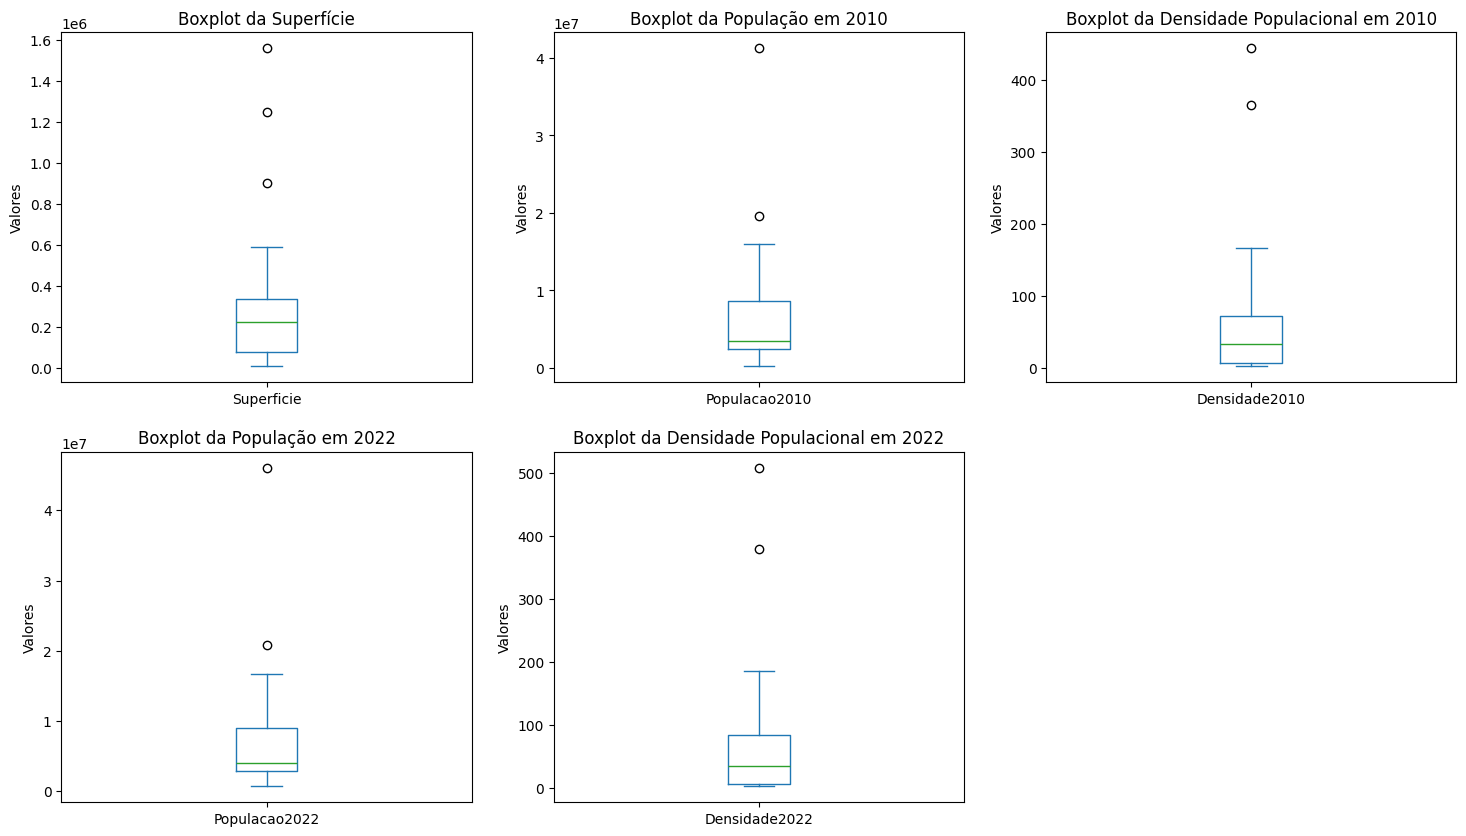

In [131]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

dados['Superficie'].plot(kind='box', ax=axs[0, 0])
axs[0, 0].set_title('Boxplot da Superfície')
axs[0, 0].set_ylabel('Valores')

dados['Populacao2010'].plot(kind='box', ax=axs[0, 1])
axs[0, 1].set_title('Boxplot da População em 2010')
axs[0, 1].set_ylabel('Valores')

dados['Densidade2010'].plot(kind='box', ax=axs[0, 2])
axs[0, 2].set_title('Boxplot da Densidade Populacional em 2010')
axs[0, 2].set_ylabel('Valores')

dados['Populacao2022'].plot(kind='box', ax=axs[1, 0])
axs[1, 0].set_title('Boxplot da População em 2022')
axs[1, 0].set_ylabel('Valores')

dados['Densidade2022'].plot(kind='box', ax=axs[1, 1])
axs[1, 1].set_title('Boxplot da Densidade Populacional em 2022')
axs[1, 1].set_ylabel('Valores')

fig.delaxes(axs[1, 2])

plt.show()

O código acima cria os boxplots para cada coluna do arquivo csv para facilitar a visualização dos outliers.

Os boxplots são formados a partir da mediana e dos quartis que foram explicados anteriormente na função describe,através das imagens obtidas é notável a presença do outliers acima de todos os boxplots, coisa que não ocorre na parte inferior. Isso significa que existem dados que estão muito acima dos outros valores.

In [132]:
def identificar_outliers(df, coluna):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
    return outliers[['Regiao', 'Estado', coluna]]

outliers_superficie = identificar_outliers(dados, 'Superficie')
outliers_populacao2010 = identificar_outliers(dados, 'Populacao2010')
outliers_densidade2010 = identificar_outliers(dados, 'Densidade2010')
outliers_populacao2022 = identificar_outliers(dados, 'Populacao2022')
outliers_densidade2022 = identificar_outliers(dados, 'Densidade2022')

print("Outliers na Superfície:\n", outliers_superficie)
print("\n")
print("Outliers na População em 2010:\n", outliers_populacao2010)
print("\n")
print("Outliers na Densidade Populacional em 2010:\n", outliers_densidade2010)
print("\n")
print("Outliers na População em 2022:\n", outliers_populacao2022)
print("\n")
print("Outliers na Densidade Populacional em 2022:\n", outliers_densidade2022)

Outliers na Superfície:
           Regiao Estado  Superficie
2          Norte     AM 1559168.117
4          Norte     PA 1245759.305
24  Centro-Oeste     MT  903206.997


Outliers na População em 2010:
      Regiao Estado  Populacao2010
16  Sudeste     MG   19597330.000
19  Sudeste     SP   41262199.000


Outliers na Densidade Populacional em 2010:
           Regiao Estado  Densidade2010
18       Sudeste     RJ        365.480
26  Centro-Oeste     DF        444.660


Outliers na População em 2022:
      Regiao Estado  Populacao2022
16  Sudeste     MG   20732660.000
19  Sudeste     SP   46024937.000


Outliers na Densidade Populacional em 2022:
           Regiao Estado  Densidade2022
18       Sudeste     RJ        379.780
26  Centro-Oeste     DF        507.460


Como visto no describe temos os seguintes dados referentes à mediana:

| Superficie | Populacao2010 | Densidade2010 | Populacao2022 | Densidade2022 |
|------------|---------------|---------------|---------------|---------------|
| 224273.831 | 3514952.000   | 33.410        | 3975100.000   | 35.350        |

Através da comparação das medianas com os outliers encontrados descobrimos se o outlier está acima do limite superior ou abaixo do limite inferior.
Os resultados encontrados no código acima são:

Para superfície:

| Região | Estado | Superficie |
|---|---|---|
| Norte | AM | 1559168.117 |
| Norte | PA | 1245759.305 |
| Centro-Oeste | MT | 903206.997 |
| Mediana | | 224273.831 |

Para População em 2010:

| Região | Estado | População em 2010 |
|---|---|---|
| Sudeste | MG | 19597330.000 |
| Sudeste | SP | 41262199.000 |
| Mediana | | 3514952.000 |

Para Densidade Populacional em 2010

| Região | Estado | Densidade 2010 |
|---|---|---|
| Sudeste | RJ | 365.480 |
| Centro-Oeste | DF | 444.660 |
| Mediana | | 33.410 |

Para População em 2022:

| Região | Estado | População 2022 |
|---|---|---|
| Sudeste | MG | 20732660.000 |
| Sudeste | SP | 46024937.000 |
| Mediana | | 3975100.000 |

Para Densidade Populacional em 2022:

| Região | Estado | Densidade 2022 |
|---|---|---|
| Sudeste | RJ | 379.780 |
| Centro-Oeste | DF | 507.460 |
| Mediana | | 35.350 |

Através dos quadros fica mais fácil notar que todos os outliers estão acima do limite superior.

In [133]:
dados_numericos = dados.drop(['Regiao', 'Estado'], axis=1)

# Calculando a correlação entre todas as variáveis numéricas
correlacao = dados_numericos.corr()

# Exibindo a matriz de correlação
print("Matriz de Correlação:")
print(correlacao)

Matriz de Correlação:
               Superficie  Populacao2010  Densidade2010  Populacao2022  \
Superficie          1.000          0.046         -0.376          0.045   
Populacao2010       0.046          1.000          0.261          0.998   
Densidade2010      -0.376          0.261          1.000          0.258   
Populacao2022       0.045          0.998          0.258          1.000   
Densidade2022      -0.372          0.254          0.998          0.252   

               Densidade2022  
Superficie            -0.372  
Populacao2010          0.254  
Densidade2010          0.998  
Populacao2022          0.252  
Densidade2022          1.000  


A correlação usa valores que vão de -1 a 1 para mostrar o quanto uma variável influência na outra sendo -1 inversamente propocional, 0 sem influência e 1 diretamente proporcional, ou seja quanto mais próximo dos extremos mais uma variável vai influenciar a outra.

Analisando o resultado do código percebe-se que as variáveis só tem índices altos com elas mesmas, ou com uma variável que representa a mesma coisa em outro ano, como densidade em 2010 e densidade 2022 que apresentam uma correlação muito próxima de 1.

Porém a densidade é calculada através da divisão entre a população pela superfície, como essa variável apresenta uma relação com 2 outras variáveis a análise seria mais complexa, mas através dos resultados já é possível perceber que a densidade é inversamente proporcional a superfície e diretamente proporcional a população. Por mais que os resultados encontrados tenham apresentado uma correlação baixa é importante notar essa dependência.

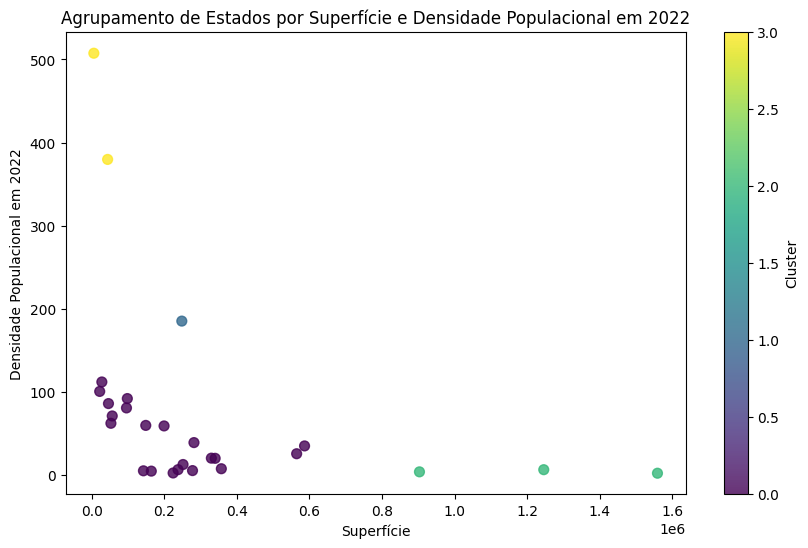


Centros dos Clusters:
   Superficie  Populacao2022  Densidade2022
0  214521.691    6000333.143         43.549
1  248219.481   46024937.000        185.420
2 1236044.806    5393154.333          4.500
3   24755.603    9769447.500        443.620


In [134]:
# Selecionar apenas as variáveis numéricas relevantes para clustering
dados_cluster = dados[['Superficie', 'Populacao2022', 'Densidade2022']]

# Padronizar os dados para facilitar o clustering
scaler = StandardScaler()
dados_cluster_scaled = scaler.fit_transform(dados_cluster)

# Aplicar o algoritmo K-means
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(dados_cluster_scaled)
dados['Cluster'] = kmeans.labels_

# Visualizar os clusters
plt.figure(figsize=(10, 6))
plt.scatter(dados['Superficie'], dados['Densidade2022'], c=dados['Cluster'], cmap='viridis', s=50, alpha=0.8)
plt.xlabel('Superfície')
plt.ylabel('Densidade Populacional em 2022')
plt.title('Agrupamento de Estados por Superfície e Densidade Populacional em 2022')
plt.colorbar(label='Cluster')
plt.show()

# Verificar os centros dos clusters
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
centros_df = pd.DataFrame(cluster_centers, columns=dados_cluster.columns)
print("\nCentros dos Clusters:")
print(centros_df)

O algoritmo K-means é usado para agrupar dados em grupos distintos com base em suas características. Aqui está como funciona:

Inicialização dos Centroides:

Escolhemos aleatoriamente k pontos iniciais como centros dos grupos. Cada ponto representa o "coração" inicial de um grupo.
Atribuição dos Pontos aos Grupos:

Para cada estado, calculamos a distância até cada centroide. O dado é atribuído ao grupo cujo centroide está mais próximo, com base na distância euclidiana.
Atualização dos Centroides:

Uma vez que todos os dados foram atribuídos a um grupo, recalculamos os centroides como a média dos dados atribuídos a cada grupo. Isso move os centroides para o centro geométrico dos dados no grupo.
Iteração até a Convergência:

Repetimos os passos de atribuição e atualização dos centroides até que os centroides parem de se mover significativamente entre as iterações ou até que um critério de parada seja alcançado.
Resumo Formal Simplificado:

In [135]:
X = dados[['Superficie', 'Populacao2010', 'Densidade2010']] 
y = dados['Densidade2022']

X = sm.add_constant(X)

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:          Densidade2022   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     2474.
Date:                Thu, 27 Jun 2024   Prob (F-statistic):           5.37e-29
Time:                        20:52:43   Log-Likelihood:                -88.284
No. Observations:                  27   AIC:                             184.6
Df Residuals:                      23   BIC:                             189.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.8386      2.339     -0.359

Tradução:

Resultados da Regressão Linear

Variáveis Dependentes e Coeficientes

- **Dependente:** Densidade2022

| Variável    | Coeficiente | Erro Padrão | Valor-p   |
|-------------|-------------|--------------|-----------|
| const       | -0.8386     | 2.339        | 0.723     |
| Superficie  | 1.808e-06   | 3.94e-06     | 0.651     |
| População2010 | -1.153e-07 | 1.68e-07     | 0.499     |
| Densidade2010 | 1.1047     | 0.014        | 0.000     |

Medidas de Ajuste do Modelo

- **R²:** 0.997
- **R² Ajustado:** 0.997
- **Estatística F:** 2474.0
- **Prob (Estatística F):** 5.37e-29

Diagnóstico do Modelo

- **Log-Likelihood:** -88.284
- **Número de Observações:** 27
- **AIC:** 184.6
- **BIC:** 189.8

Testes de Normalidade dos Resíduos

- **Omnibus:** 12.105, **Prob(Omnibus):** 0.002
- **Jarque-Bera (JB):** 23.012, **Prob(JB):** 1.01e-05
- **Assimetria (Skew):** -0.621
- **Curtose (Kurtosis):** 7.349

Condição do Modelo

- **Número de Condição:** 1.91e+07

Notas:
1. Erros Padrão assumem que a matriz de covariância dos erros é corretamente especificada.
2. O número de condição é grande (1.91e+07), o que pode indicar a presença de multicolinearidade forte ou outros problemas numéricos..


Resultados da Regressão Linear

Influência das Variáveis:

Superfície: Aumentos na área não mostraram uma relação forte com mudanças na densidade populacional em 2022. Isso significa que o tamanho do estado não é um fator determinante na densidade populacional futura.

População em 2010: A população em 2010 também não teve uma influência estatisticamente significativa na densidade populacional em 2022. Ou seja, o tamanho da população de uma década atrás não prevê de forma robusta como será a densidade populacional atual.

Densidade em 2010: Por outro lado, a densidade populacional em 2010 teve um impacto forte e positivo na densidade populacional em 2022. Isso significa que regiões mais densamente povoadas há uma década tendem a manter ou aumentar essa densidade ao longo do tempo.

Qualidade do Modelo:

O modelo explica muito bem a variação na densidade populacional em 2022, com 99.7% de precisão. Isso mostra que as variáveis usadas são poderosas para prever como a densidade populacional evolui ao longo dos anos.
Diagnóstico do Modelo:

Os resíduos do modelo não seguem perfeitamente uma distribuição normal, sugerindo que há alguns padrões nos dados que o modelo não captura totalmente.

Existe uma alta correlação entre as variáveis independentes usadas no modelo, o que pode afetar a precisão dos resultados.

Esses resultados ajudam a entender como características demográficas passadas podem afetar a densidade populacional futura, fornecendo insights valiosos para políticas públicas e planejamento urbano.

In [137]:
modelo = sm.OLS(y, X).fit()

# Fazer previsões usando o modelo ajustado
previsao = modelo.predict(X)

# Adicionar as previsões ao DataFrame original
dados['Previsao_Densidade2022'] = previsao

# Encontrar a região com o maior crescimento previsto de densidade populacional
regiao_maior_crescimento = dados.loc[dados['Previsao_Densidade2022'].idxmax(), 'Regiao']

print(f"A região com maior crescimento previsto de densidade populacional é: {regiao_maior_crescimento}")


A região com maior crescimento previsto de densidade populacional é: Centro-Oeste


Quando ajustamos um modelo de regressão linear utilizando Ordinary Least Squares (OLS), estamos basicamente tentando encontrar a melhor linha reta que se ajusta aos nossos dados. Isso é feito de forma a minimizar a soma dos quadrados das diferenças entre os valores reais dos nossos dados e os valores preditos pelo modelo.

Ordinary Least Squares (OLS): É um método matemático que calcula os coeficientes (ou pesos) para cada variável explicativa (como Superfície, População de 2010, etc.) de modo a minimizar os erros de previsão. Em termos simples, ele ajusta os pesos de cada variável para que a linha reta resultante seja a mais próxima possível dos dados reais.

Ajustar o modelo: Este processo envolve usar os dados históricos (como a densidade populacional passada e outras variáveis) para calcular esses coeficientes. Assim, podemos usar o modelo ajustado para fazer previsões sobre a densidade populacional futura com base nos padrões observados nos dados anteriores.

Regressão Linear: É o método utilizado aqui para entender como uma ou mais variáveis independentes (como Superfície, População de 2010, etc.) estão relacionadas à variável dependente (Densidade de 2022). O objetivo é entender essas relações e usá-las para fazer previsões.

Ao final do processo, teremos não apenas uma linha que melhor se ajusta aos dados existentes, mas também uma maneira de prever como a densidade populacional pode mudar no futuro com base nas variáveis que consideramos importantes. Isso é útil para entender tendências demográficas e tomar decisões informadas.